In [29]:
#importing libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns
import json

In [30]:
#importing train,test,split,logisticregression and standardScaler from sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

In [31]:
#loading the dataset
df = pd.read_csv('../../cleaned_data/titanic_cleaned.csv')

In [32]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0.0
1,1,1,0,38.0,1,0,71.2833,1.0
2,1,3,0,26.0,0,0,7.9250,0.0
3,1,1,0,35.0,1,0,53.1000,0.0
4,0,3,1,35.0,0,0,8.0500,0.0


In [33]:
#feature x and target y
X = df.drop('Survived', axis=1)
y = df['Survived']


In [34]:
#spliting data 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
#filling NaN values
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [36]:
#standardScaler normalizes features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) 


In [37]:
#now_creating_and_training the model
model_lr = LogisticRegression(max_iter=200, random_state=42)
model_lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [38]:
#making_predictions
y_pred = model_lr.predict(X_test_scaled)
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]



In [39]:
#counting model_accuracy 
accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_prob)

print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'  ROC-AUC  : {auc:.4f}')
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

  Accuracy : 0.8045 (80.4%)
  ROC-AUC  : 0.8432
              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



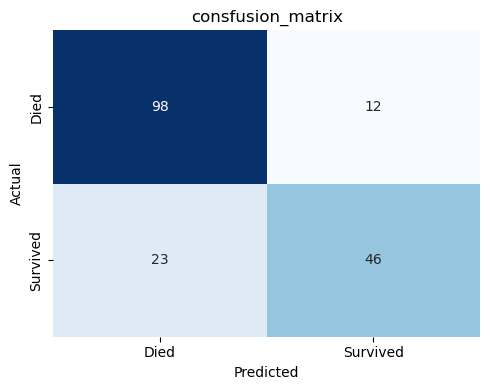

In [40]:
#confusion matrix
fig, ax = plt.subplots(figsize=(5,4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax = ax,
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'],
                cbar=False)
ax.set_title('consfusion_matrix')    
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')


plt.tight_layout()
plt.show()              
   

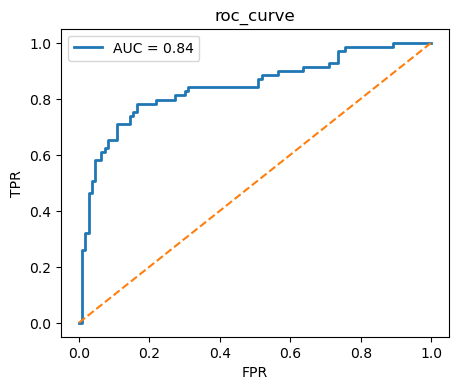

In [41]:
#roc_curve
fig, ax = plt.subplots(figsize=(5,4))

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.2f}')
ax.plot([0, 1], [0, 1], linestyle='--')

ax.set_title('roc_curve')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()

plt.show()

In [42]:
#saving model result in json for comparison in Notebook 3
results = {
    'logistic_regression': {
        'accuracy': round(accuracy, 4),
        'roc_auc': round(auc, 4)
    }
}

with open('model_results.json', 'w') as f:
    json.dump(results, f)